In [1]:
import pickle

with open('homologs/car_catres_mapping.pkl', 'rb') as f:
    data = pickle.load(f)

data

{'A0A010YLP6': {'cat_His': {'col': 629, 'aa': 'H', 'resid_1based': 296},
  'cat_Thr': {'col': 831, 'aa': 'T', 'resid_1based': 409},
  'A10_Lys': {'col': 1057, 'aa': 'K', 'resid_1based': 605},
  'PCP_Ser': {'col': 1144, 'aa': 'S', 'resid_1based': 678}},
 'A0A024JSK2': {'cat_His': {'col': 629, 'aa': 'H', 'resid_1based': 311},
  'cat_Thr': {'col': 831, 'aa': 'T', 'resid_1based': 432},
  'A10_Lys': {'col': 1057, 'aa': 'K', 'resid_1based': 628},
  'PCP_Ser': {'col': 1144, 'aa': 'S', 'resid_1based': 701}},
 'A0A024JWI0': {'cat_His': {'col': 629, 'aa': 'H', 'resid_1based': 294},
  'cat_Thr': {'col': 831, 'aa': 'T', 'resid_1based': 407},
  'A10_Lys': {'col': 1057, 'aa': 'K', 'resid_1based': 601},
  'PCP_Ser': {'col': 1144, 'aa': 'S', 'resid_1based': 674}},
 'A0A024JZE3': {'cat_His': {'col': 629, 'aa': 'H', 'resid_1based': 306},
  'cat_Thr': {'col': 831, 'aa': 'T', 'resid_1based': 425},
  'A10_Lys': {'col': 1057, 'aa': 'K', 'resid_1based': 614},
  'PCP_Ser': {'col': 1144, 'aa': 'S', 'resid_1bas

In [ ]:
import os
import glob
import pandas as pd
import pyrosetta

# ligand(adi/amp 등)는 params가 없으면 인식이 안 되므로 무시하고 단백질 에너지만 비교.
# 필요하면 subs/*.mol2 로 params 생성해서 ligand 포함 scoring으로 확장 가능.
pyrosetta.init("-ignore_unrecognized_res true -mute all")

sfxn = pyrosetta.get_score_function()  # ref2015

pre_dir  = "inputs/rosetta/carA_holo_adi_amp_homologs"   # relax 이전:  ID.pdb
post_dir = "inputs/placer/carA_holo_adi_amp_homologs"    # relax 이후:  ID.relax.pdb

# 각 폴더에서 ID -> 파일경로 매핑
pre_map  = {os.path.basename(p)[:-len(".pdb")]: p
            for p in glob.glob(os.path.join(pre_dir, "*.pdb"))}
post_map = {os.path.basename(p)[:-len(".relax.pdb")]: p
            for p in glob.glob(os.path.join(post_dir, "*.relax.pdb"))}

# 양쪽에 모두 존재하는 ID만 비교
common_ids = sorted(set(pre_map) & set(post_map))
print(f"pre={len(pre_map)}, post={len(post_map)}, common={len(common_ids)}")

def score_pdb(path):
    try:
        pose = pyrosetta.pose_from_pdb(path)
        return sfxn(pose)
    except Exception as e:
        print(f"[skip] {path}: {e}")
        return None

rows = []
for i, pdb_id in enumerate(common_ids, 1):
    e_pre  = score_pdb(pre_map[pdb_id])
    e_post = score_pdb(post_map[pdb_id])
    rows.append({
        "ID": pdb_id,
        "energy_pre_relax": e_pre,
        "energy_post_relax": e_post,
        "delta": (e_post - e_pre) if (e_pre is not None and e_post is not None) else None,
    })
    if i % 50 == 0:
        print(f"  ...{i}/{len(common_ids)} done")

df_energy = pd.DataFrame(rows).set_index("ID")
df_energy


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_relax = pd.read_csv("inputs/placer/carA_holo_adi_amp_homologs/relax_metrics.tsv", sep="\t")

pre  = df_relax["pre_bound"].dropna()
post = df_relax["post_bound"].dropna()

# 두 분포를 같은 bin으로 겹쳐 그려야 비교가 됨
lo, hi = min(pre.min(), post.min()), max(pre.max(), post.max())
bins = np.linspace(lo, hi, 50)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pre,  bins=bins, alpha=0.5, color="tab:blue",   label=f"pre_relax  (median={pre.median():.0f})")
ax.hist(post, bins=bins, alpha=0.5, color="tab:orange", label=f"post_relax (median={post.median():.0f})")

# 밀집 위치(중앙값) 표시
ax.axvline(pre.median(),  color="tab:blue",   ls="--", lw=1)
ax.axvline(post.median(), color="tab:orange", ls="--", lw=1)

ax.set_xlabel("Stability (REU, ref2015 total_score; lower = more stable)")
ax.set_ylabel("count")
ax.set_title("carA_holo_adi_amp: pre vs post relax stability distribution")
ax.legend()
fig.tight_layout()
plt.show()


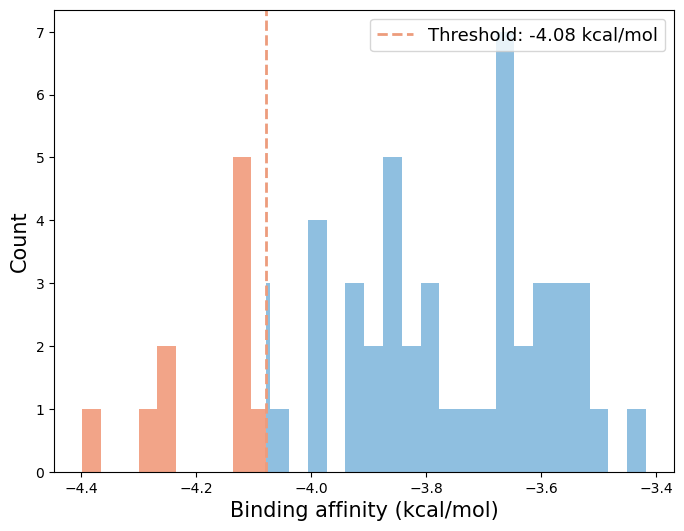

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df  = pd.read_csv('results/20260715_carA_holo_6aca_amp_homologs_nac_po_ds_candidates.csv')
aff = df['affinity_mean'].dropna().values

# threshold = midpoint between 10th and 11th strongest → exactly 10 fall on the orange side
srt       = np.sort(aff)
threshold = (srt[9] + srt[10]) / 2

# regular bins, then insert the threshold as an edge so its bin is split there
bins = np.unique(np.append(np.histogram_bin_edges(aff, bins=30), threshold))

fig, ax = plt.subplots(figsize=(8, 6))
n, edges, patches = ax.hist(aff, bins=bins)          # no edgecolor → no border lines
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor('#f2a488' if left < threshold else '#8fbfe0')

ax.axvline(threshold, color='#ed9c7c', linestyle='--', linewidth=2,
           label=f'Threshold: {threshold:.2f} kcal/mol')

ax.set_xlabel('Binding affinity (kcal/mol)', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.legend(fontsize=13)

plt.savefig('figs/binding_affinity_distribution_6apa.png', dpi=300, bbox_inches='tight')
plt.show()

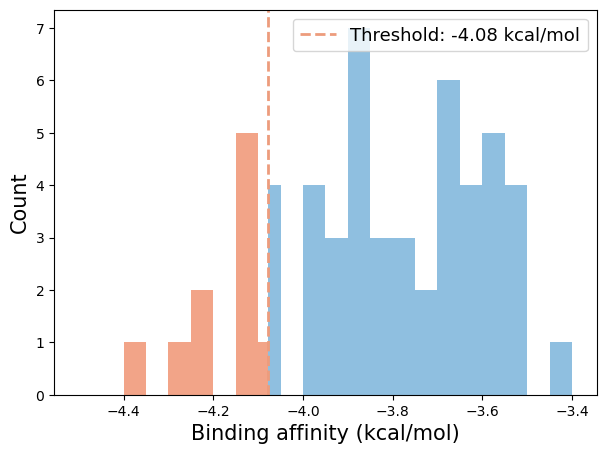

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df  = pd.read_csv('results/20260715_carA_holo_6aca_amp_homologs_nac_po_ds_candidates.csv')
aff = df['affinity_mean'].dropna().values

bin_start = -4.5
bin_end   = -3.4
bin_step  = 0.05

# threshold = 10번째와 11번째 사이 → 정확히 10개가 orange 쪽에
srt       = np.sort(aff)
threshold = (srt[9] + srt[10]) / 2

# 지정한 범위로 bin 생성 후, threshold를 edge로 삽입해 그 bin을 쪼갬
bins = np.arange(bin_start, bin_end + bin_step, bin_step)
bins = np.unique(np.append(bins, threshold))

fig, ax = plt.subplots(figsize=(7, 5))
n, edges, patches = ax.hist(aff, bins=bins)          # edgecolor 없음 → 경계선 없음
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor('#f2a488' if left < threshold else '#8fbfe0')

ax.axvline(threshold, color='#ed9c7c', linestyle='--', linewidth=2,
           label=f'Threshold: {threshold:.2f} kcal/mol')

ax.set_xlabel('Binding affinity (kcal/mol)', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.legend(fontsize=13)

plt.savefig('figs/binding_affinity_distribution_6apa.png', dpi=300, bbox_inches='tight')
plt.show()